In [28]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


ROOT = Path(r"A:\NCA_DATA\S2_2016-2017")
GEE_READY_DIR = ROOT / "gee_ready"

OUT_DIR = ROOT / "qa60_scl_monthly_panels"
from pathlib import Path
import re

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


ROOT = Path(
    r"A:\NCA_DATA\S2_2016-2017"
)

GEE_READY_DIR = (
    ROOT / "gee_ready"
)

OUT_DIR = (
    ROOT / "qa60_scl_diagnostic_panels"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


EXPECTED_BANDS = [
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B11",
    "B12",
    "SCL",
    "QA60",
]


print(
    "Input:",
    GEE_READY_DIR
)

print(
    "Output:",
    OUT_DIR
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input directory:", GEE_READY_DIR)
print("Output directory:", OUT_DIR)

Input: A:\NCA_DATA\S2_2016-2017\gee_ready
Output: A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_panels
Input directory: A:\NCA_DATA\S2_2016-2017\gee_ready
Output directory: A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_panels


In [29]:
def parse_sensing_datetime(
    file_name,
):
    match = re.search(
        r"_([0-9]{8}T[0-9]{6})_",
        file_name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse sensing time from {file_name}"
        )

    return pd.to_datetime(
        match.group(1),
        format="%Y%m%dT%H%M%S",
    )


def parse_mgrs_tile(
    file_name,
):
    match = re.search(
        r"_T(11TNH|11TNJ|11TPH)_",
        file_name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse MGRS tile from {file_name}"
        )

    return match.group(1)


records = []
errors = []


for tif_path in sorted(
    GEE_READY_DIR.glob(
        "*_GEE.tif"
    )
):

    try:

        dt = parse_sensing_datetime(
            tif_path.name
        )

        mgrs_tile = parse_mgrs_tile(
            tif_path.name
        )

        with rasterio.open(
            tif_path
        ) as src:

            if src.count != 12:
                continue

            if list(
                src.descriptions
            ) != EXPECTED_BANDS:
                continue

        records.append({
            "tif_path": tif_path,
            "file_name": tif_path.name,
            "datetime": dt,
            "year": dt.year,
            "month": dt.month,
            "mgrs_tile": mgrs_tile,
        })

    except Exception as exc:

        errors.append({
            "file": tif_path.name,
            "error": repr(exc),
        })


inventory = (
    pd.DataFrame(
        records
    )
    .sort_values(
        [
            "datetime",
            "mgrs_tile",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "QA60-enabled TIFFs:",
    len(inventory)
)

print(
    "Inventory errors:",
    len(errors)
)

print(
    "\nBy tile:"
)

display(
    inventory[
        "mgrs_tile"
    ]
    .value_counts()
    .rename_axis(
        "mgrs_tile"
    )
    .reset_index(
        name="count"
    )
)

display(
    inventory.head()
)

QA60-enabled TIFFs: 562
Inventory errors: 0

By tile:


,mgrs_tile,count
0,11TPH,212
1,11TNH,175
2,11TNJ,175


,tif_path,file_name,datetime,year,month,mgrs_tile
0,A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_...,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_2...,2016-01-03 18:51:22,2016,1,11TNH
1,A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_...,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_2...,2016-01-03 18:51:22,2016,1,11TNJ
2,A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_...,S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_2...,2016-01-03 18:51:22,2016,1,11TPH
3,A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_...,S2A_MSIL2A_20160110T184122_N0500_R027_T11TNH_2...,2016-01-10 18:41:22,2016,1,11TNH
4,A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_...,S2A_MSIL2A_20160110T184122_N0500_R027_T11TNJ_2...,2016-01-10 18:41:22,2016,1,11TNJ


In [30]:
TILES = [
    "11TNH",
    "11TNJ",
    "11TPH",
]


monthly = (
    inventory.loc[
        inventory[
            "year"
        ].isin(
            [2016, 2017]
        )
        &
        inventory[
            "mgrs_tile"
        ].isin(
            TILES
        )
    ]
    .sort_values(
        "datetime"
    )
    .groupby(
        [
            "year",
            "month",
            "mgrs_tile",
        ],
        as_index=False,
    )
    .first()
    .sort_values(
        [
            "year",
            "month",
            "mgrs_tile",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Monthly tile-scenes selected:",
    len(monthly)
)

display(
    monthly[
        [
            "year",
            "month",
            "mgrs_tile",
            "datetime",
            "file_name",
        ]
    ]
)

Monthly tile-scenes selected: 72


,year,month,mgrs_tile,datetime,file_name
0,2016,1,11TNH,2016-01-03 18:51:22,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_2...
1,2016,1,11TNJ,2016-01-03 18:51:22,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_2...
2,2016,1,11TPH,2016-01-03 18:51:22,S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_2...
3,2016,2,11TNH,2016-02-02 18:51:12,S2A_MSIL2A_20160202T185112_N0500_R070_T11TNH_2...
4,2016,2,11TNJ,2016-02-02 18:51:12,S2A_MSIL2A_20160202T185112_N0500_R070_T11TNJ_2...
...,...,...,...,...,...
67,2017,11,11TNJ,2017-11-03 18:51:21,S2A_MSIL2A_20171103T185121_N0500_R070_T11TNJ_2...
68,2017,11,11TPH,2017-11-03 18:51:21,S2A_MSIL2A_20171103T185121_N0500_R070_T11TPH_2...
69,2017,12,11TNH,2017-12-03 18:47:41,S2A_MSIL2A_20171203T184741_N0500_R070_T11TNH_2...
70,2017,12,11TNJ,2017-12-03 18:47:41,S2A_MSIL2A_20171203T184741_N0500_R070_T11TNJ_2...


In [31]:
# ------------------------------------------------------------
# Production-style SCL exclusions
# ------------------------------------------------------------
#
# Mask:
#   0  = no data
#   1  = saturated / defective
#   3  = cloud shadow
#   7  = unclassified
#   8  = cloud medium probability
#   9  = cloud high probability
#   10 = thin cirrus
#   11 = snow / ice
#
# Keep:
#   2  = dark area pixels
#   4  = vegetation
#   5  = bare soils
#   6  = water
# ------------------------------------------------------------

SCL_MASKED_CLASSES = [
    0,
    1,
    3,
    7,
    8,
    9,
    10,
    11,
]


def build_scl_mask(
    scl,
):
    """
    Returns:
        scl_bad  = True where pixel is masked
        scl_keep = True where pixel is retained
    """

    scl_bad = np.isin(
        scl,
        SCL_MASKED_CLASSES,
    )

    scl_keep = (
        ~scl_bad
    )

    return (
        scl_bad,
        scl_keep,
    )


def build_qa60_mask(
    qa60,
):
    """
    QA60:
        bit 10 = opaque cloud
        bit 11 = cirrus

    Returns:
        opaque
        cirrus
        qa_bad
        qa_keep
    """

    opaque = (
        qa60
        &
        (1 << 10)
    ) != 0

    cirrus = (
        qa60
        &
        (1 << 11)
    ) != 0

    qa_bad = (
        opaque
        |
        cirrus
    )

    qa_keep = (
        ~qa_bad
    )

    return (
        opaque,
        cirrus,
        qa_bad,
        qa_keep,
    )

In [32]:
def read_scene(
    tif_path,
):
    """
    Read only the bands needed for
    this diagnostic.
    """

    with rasterio.open(
        tif_path
    ) as src:

        # B4/B3/B2
        red = (
            src.read(3)
            .astype(
                np.float32
            )
        )

        green = (
            src.read(2)
            .astype(
                np.float32
            )
        )

        blue = (
            src.read(1)
            .astype(
                np.float32
            )
        )

        scl = (
            src.read(11)
            .astype(
                np.uint8
            )
        )

        qa60 = (
            src.read(12)
            .astype(
                np.uint16
            )
        )

    return (
        red,
        green,
        blue,
        scl,
        qa60,
    )


def make_rgb(
    red,
    green,
    blue,
):
    """
    Per-band 2–98 percentile stretch.
    """

    rgb = np.stack(
        [
            red,
            green,
            blue,
        ],
        axis=-1,
    )

    out = np.zeros_like(
        rgb,
        dtype=np.float32,
    )

    for i in range(3):

        band = rgb[
            ...,
            i,
        ]

        valid = (
            band > 0
        )

        if valid.sum() == 0:
            continue

        lo, hi = np.percentile(
            band[valid],
            [
                2,
                98,
            ],
        )

        if hi <= lo:
            hi = lo + 1

        out[
            ...,
            i,
        ] = np.clip(
            (
                band
                - lo
            )
            /
            (
                hi
                - lo
            ),
            0,
            1,
        )

    return out

In [33]:
# ------------------------------------------------------------
# Raw SCL
# ------------------------------------------------------------

SCL_LABELS = {
    0: "No data",
    1: "Saturated / defective",
    2: "Dark area pixels",
    3: "Cloud shadows",
    4: "Vegetation",
    5: "Bare soils",
    6: "Water",
    7: "Unclassified",
    8: "Cloud medium prob.",
    9: "Cloud high prob.",
    10: "Thin cirrus",
    11: "Snow / ice",
}


SCL_COLORS = [
    "#000000",
    "#ff0000",
    "#2f2f2f",
    "#6a5acd",
    "#00a000",
    "#d2b48c",
    "#0000ff",
    "#808080",
    "#c0c0c0",
    "#ffffff",
    "#00ffff",
    "#ffb6c1",
]


SCL_CMAP = ListedColormap(
    SCL_COLORS
)

SCL_NORM = BoundaryNorm(
    np.arange(
        -0.5,
        12.5,
        1,
    ),
    SCL_CMAP.N,
)


# ------------------------------------------------------------
# Raw QA60
# ------------------------------------------------------------

QA60_CMAP = ListedColormap([
    "#000000",  # 0 clear
    "#ffff00",  # opaque
    "#00ffff",  # cirrus
    "#ff00ff",  # both
])

QA60_NORM = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5,
        2.5,
        3.5,
    ],
    QA60_CMAP.N,
)


# ------------------------------------------------------------
# Binary keep/mask display
# ------------------------------------------------------------

KEEP_MASK_CMAP = ListedColormap([
    "#000000",  # keep
    "#ffffff",  # mask
])

KEEP_MASK_NORM = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5,
    ],
    KEEP_MASK_CMAP.N,
)


# ------------------------------------------------------------
# Final comparison
#
# 0 = kept by both
# 1 = masked QA60 only
# 2 = masked SCL only
# 3 = masked by both
# ------------------------------------------------------------

COMPARE_CMAP = ListedColormap([
    "#000000",
    "#ff0000",
    "#0000ff",
    "#ffff00",
])

COMPARE_NORM = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5,
        2.5,
        3.5,
    ],
    COMPARE_CMAP.N,
)

In [34]:
def qa60_display_codes(
    qa60,
):
    """
    Convert QA60 bit values to:
        0 = clear
        1 = opaque cloud
        2 = cirrus
        3 = both
    """

    opaque = (
        qa60
        &
        (1 << 10)
    ) != 0

    cirrus = (
        qa60
        &
        (1 << 11)
    ) != 0

    out = np.zeros_like(
        qa60,
        dtype=np.uint8,
    )

    out[
        opaque
        &
        (~cirrus)
    ] = 1

    out[
        (~opaque)
        &
        cirrus
    ] = 2

    out[
        opaque
        &
        cirrus
    ] = 3

    return out

In [35]:
def build_mask_comparison(
    scl_bad,
    qa_bad,
):
    """
    0 = kept by both
    1 = masked by QA60 only
    2 = masked by SCL only
    3 = masked by both
    """

    comparison = np.zeros(
        scl_bad.shape,
        dtype=np.uint8,
    )

    # QA60 only
    comparison[
        qa_bad
        &
        (~scl_bad)
    ] = 1

    # SCL only
    comparison[
        (~qa_bad)
        &
        scl_bad
    ] = 2

    # both
    comparison[
        qa_bad
        &
        scl_bad
    ] = 3

    return comparison

In [36]:
def make_diagnostic_panel(
    tif_path,
    title_text=None,
    save_path=None,
    show=True,
):

    (
        red,
        green,
        blue,
        scl,
        qa60,
    ) = read_scene(
        tif_path
    )


    rgb = make_rgb(
        red,
        green,
        blue,
    )


    (
        scl_bad,
        scl_keep,
    ) = build_scl_mask(
        scl
    )


    (
        opaque,
        cirrus,
        qa_bad,
        qa_keep,
    ) = build_qa60_mask(
        qa60
    )


    qa60_codes = (
        qa60_display_codes(
            qa60
        )
    )


    comparison = (
        build_mask_comparison(
            scl_bad,
            qa_bad,
        )
    )


    total = int(
        scl.size
    )


    kept_both = int(
        (
            comparison
            == 0
        ).sum()
    )

    qa_only = int(
        (
            comparison
            == 1
        ).sum()
    )

    scl_only = int(
        (
            comparison
            == 2
        ).sum()
    )

    masked_both = int(
        (
            comparison
            == 3
        ).sum()
    )


    if title_text is None:
        title_text = (
            tif_path.name
        )


    fig, axes = plt.subplots(
        2,
        3,
        figsize=(
            18,
            12,
        ),
    )

    axes = axes.ravel()


    # ==========================================================
    # 1. RGB
    # ==========================================================

    axes[0].imshow(
        rgb
    )

    axes[0].set_title(
        "1. RGB (B4/B3/B2)"
    )

    axes[0].axis(
        "off"
    )


    # ==========================================================
    # 2. Raw SCL
    # ==========================================================

    axes[1].imshow(
        scl,
        cmap=SCL_CMAP,
        norm=SCL_NORM,
        interpolation="nearest",
    )

    axes[1].set_title(
        "2. Raw SCL"
    )

    axes[1].axis(
        "off"
    )


    scl_handles = [

        Patch(
            facecolor=SCL_COLORS[value],
            edgecolor="black",
            label=(
                f"{value}: "
                f"{SCL_LABELS[value]}"
            ),
        )

        for value
        in range(12)
    ]


    axes[1].legend(
        handles=scl_handles,
        loc="upper left",
        bbox_to_anchor=(
            1.01,
            1.0,
        ),
        fontsize=7,
        frameon=True,
    )


    # ==========================================================
    # 3. Raw QA60
    # ==========================================================

    axes[2].imshow(
        qa60_codes,
        cmap=QA60_CMAP,
        norm=QA60_NORM,
        interpolation="nearest",
    )

    axes[2].set_title(
        "3. Raw QA60"
    )

    axes[2].axis(
        "off"
    )


    qa_handles = [

        Patch(
            facecolor="#000000",
            edgecolor="black",
            label="Clear",
        ),

        Patch(
            facecolor="#ffff00",
            edgecolor="black",
            label="Opaque cloud — bit 10",
        ),

        Patch(
            facecolor="#00ffff",
            edgecolor="black",
            label="Cirrus — bit 11",
        ),

        Patch(
            facecolor="#ff00ff",
            edgecolor="black",
            label="Opaque + cirrus",
        ),
    ]


    axes[2].legend(
        handles=qa_handles,
        loc="upper left",
        bbox_to_anchor=(
            1.01,
            1.0,
        ),
        fontsize=8,
        frameon=True,
    )


    # ==========================================================
    # 4. Final SCL mask
    #
    # 0 = keep
    # 1 = mask
    # ==========================================================

    axes[3].imshow(
        scl_bad.astype(
            np.uint8
        ),
        cmap=KEEP_MASK_CMAP,
        norm=KEEP_MASK_NORM,
        interpolation="nearest",
    )

    axes[3].set_title(
        "4. Final SCL mask\n"
        f"masked: "
        f"{scl_bad.sum():,} "
        f"({scl_bad.mean():.1%})"
    )

    axes[3].axis(
        "off"
    )


    binary_handles = [

        Patch(
            facecolor="#000000",
            edgecolor="black",
            label="Keep",
        ),

        Patch(
            facecolor="#ffffff",
            edgecolor="black",
            label="Mask",
        ),
    ]


    axes[3].legend(
        handles=binary_handles,
        loc="upper left",
        bbox_to_anchor=(
            1.01,
            1.0,
        ),
        fontsize=8,
        frameon=True,
    )


    # ==========================================================
    # 5. Final QA60 mask
    # ==========================================================

    axes[4].imshow(
        qa_bad.astype(
            np.uint8
        ),
        cmap=KEEP_MASK_CMAP,
        norm=KEEP_MASK_NORM,
        interpolation="nearest",
    )

    axes[4].set_title(
        "5. Final QA60 mask\n"
        f"masked: "
        f"{qa_bad.sum():,} "
        f"({qa_bad.mean():.1%})"
    )

    axes[4].axis(
        "off"
    )


    axes[4].legend(
        handles=binary_handles,
        loc="upper left",
        bbox_to_anchor=(
            1.01,
            1.0,
        ),
        fontsize=8,
        frameon=True,
    )


    # ==========================================================
    # 6. Final mask comparison
    # ==========================================================

    axes[5].imshow(
        comparison,
        cmap=COMPARE_CMAP,
        norm=COMPARE_NORM,
        interpolation="nearest",
    )


    axes[5].set_title(
        "6. SCL vs QA60 final mask\n"
        f"QA60-only: "
        f"{qa_only/total:.1%} | "
        f"SCL-only: "
        f"{scl_only/total:.1%}"
    )

    axes[5].axis(
        "off"
    )


    comparison_handles = [

        Patch(
            facecolor="#000000",
            edgecolor="black",
            label=(
                f"Kept by both "
                f"({kept_both/total:.1%})"
            ),
        ),

        Patch(
            facecolor="#ff0000",
            edgecolor="black",
            label=(
                f"QA60-only masked "
                f"({qa_only/total:.1%})"
            ),
        ),

        Patch(
            facecolor="#0000ff",
            edgecolor="black",
            label=(
                f"SCL-only masked "
                f"({scl_only/total:.1%})"
            ),
        ),

        Patch(
            facecolor="#ffff00",
            edgecolor="black",
            label=(
                f"Masked by both "
                f"({masked_both/total:.1%})"
            ),
        ),
    ]


    axes[5].legend(
        handles=comparison_handles,
        loc="upper left",
        bbox_to_anchor=(
            1.01,
            1.0,
        ),
        fontsize=8,
        frameon=True,
    )


    fig.suptitle(
        title_text,
        fontsize=16,
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96,
        ]
    )


    if save_path is not None:

        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )


    if show:

        plt.show()

    else:

        plt.close(
            fig
        )


    return {
        "total_pixels": total,

        "scl_masked": int(
            scl_bad.sum()
        ),

        "qa60_masked": int(
            qa_bad.sum()
        ),

        "kept_by_both": (
            kept_both
        ),

        "qa60_only_masked": (
            qa_only
        ),

        "scl_only_masked": (
            scl_only
        ),

        "masked_by_both": (
            masked_both
        ),

        "opaque_cloud": int(
            opaque.sum()
        ),

        "cirrus": int(
            cirrus.sum()
        ),
    }

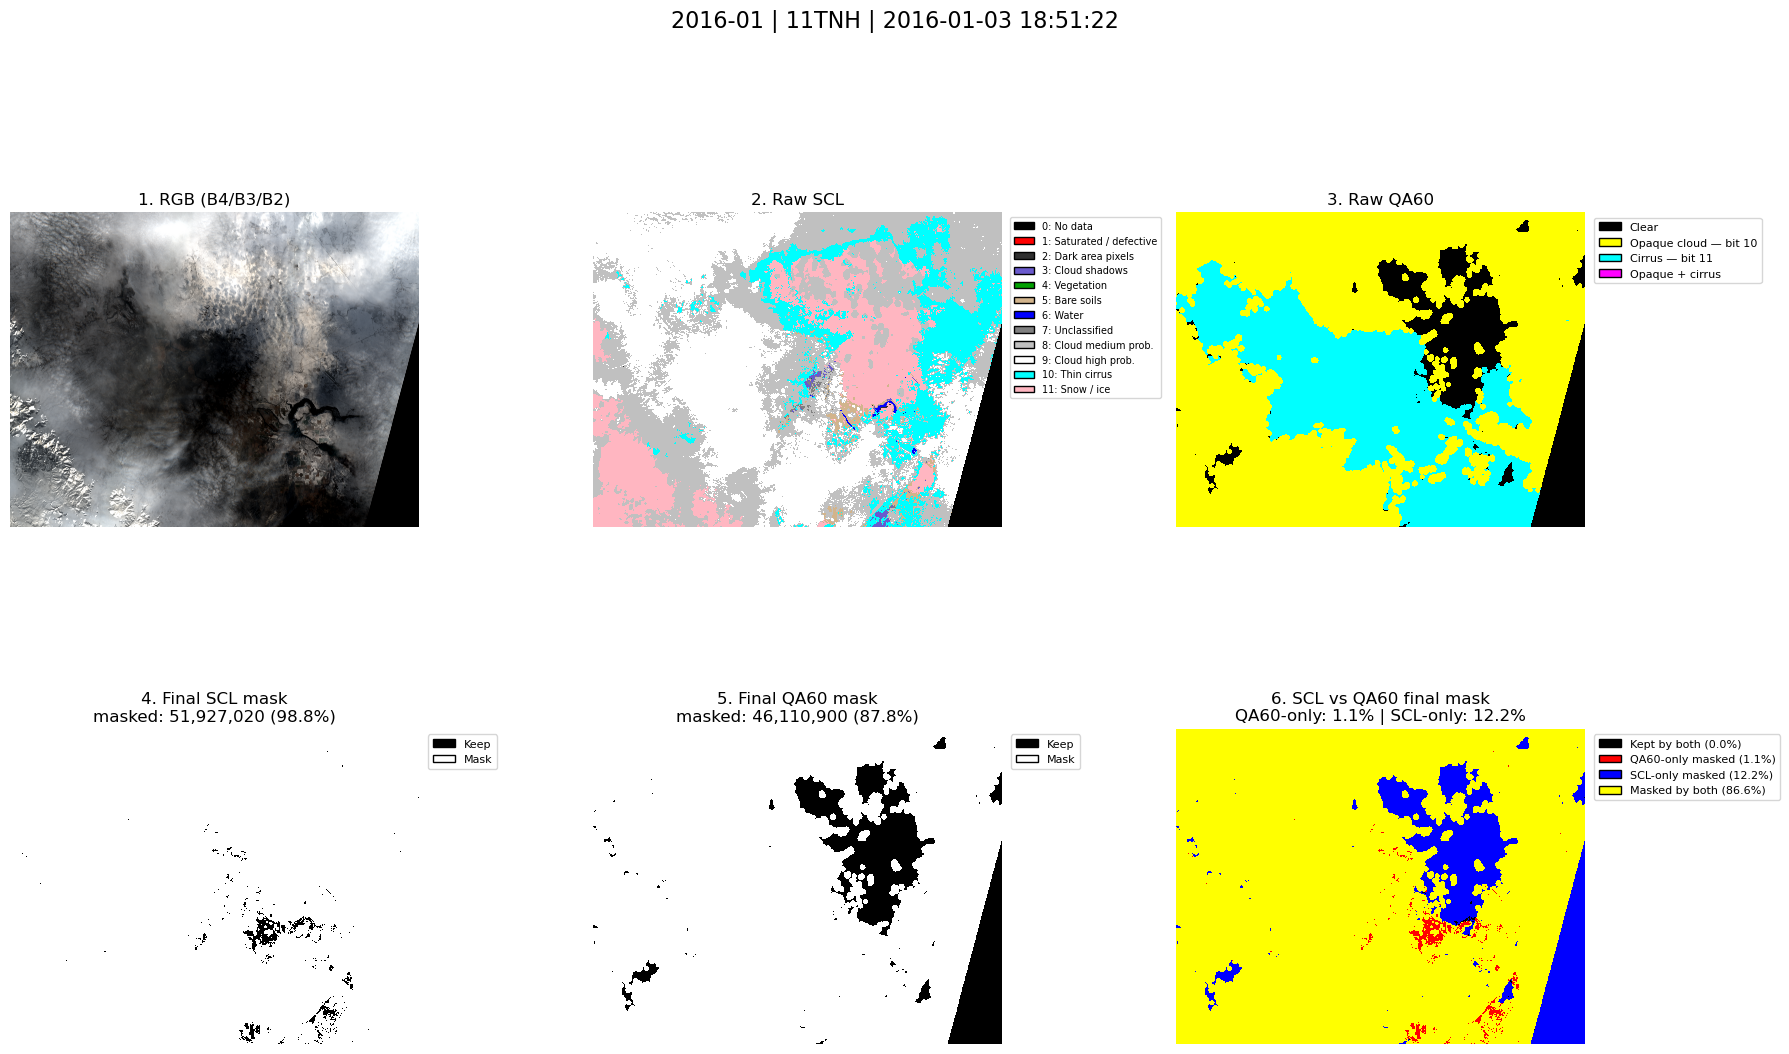

,total_pixels,scl_masked,qa60_masked,kept_by_both,qa60_only_masked,scl_only_masked,masked_by_both,opaque_cloud,cirrus
0,52544964,51927020,46110900,24036,593908,6410028,45516992,31278156,14832744


In [37]:
test_row = (
    monthly.loc[
        (
            monthly["year"] == 2016
        )
        &
        (
            monthly["month"] == 1
        )
        &
        (
            monthly["mgrs_tile"] == "11TNH"
        )
    ]
    .iloc[0]
)


test_tif = Path(
    test_row[
        "tif_path"
    ]
)


title_text = (
    f"{test_row['year']}-"
    f"{test_row['month']:02d}"
    f" | "
    f"{test_row['mgrs_tile']}"
    f" | "
    f"{test_row['datetime']:%Y-%m-%d %H:%M:%S}"
)


stats = (
    make_diagnostic_panel(
        tif_path=test_tif,
        title_text=title_text,
        save_path=None,
        show=True,
    )
)


display(
    pd.DataFrame(
        [stats]
    )
)

In [38]:
monthly_results = []


for _, row in monthly.iterrows():

    tif_path = Path(
        row[
            "tif_path"
        ]
    )

    year = int(
        row[
            "year"
        ]
    )

    month = int(
        row[
            "month"
        ]
    )

    mgrs_tile = row[
        "mgrs_tile"
    ]

    dt = row[
        "datetime"
    ]


    tile_out_dir = (
        OUT_DIR
        /
        mgrs_tile
    )

    tile_out_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    out_path = (
        tile_out_dir
        /
        (
            f"{year}_"
            f"{month:02d}_"
            f"{mgrs_tile}_"
            f"SCL_QA60_diagnostic.png"
        )
    )


    title_text = (
        f"{year}-"
        f"{month:02d}"
        f" | "
        f"{mgrs_tile}"
        f" | "
        f"{dt:%Y-%m-%d %H:%M:%S}"
    )


    stats = (
        make_diagnostic_panel(
            tif_path=tif_path,
            title_text=title_text,
            save_path=out_path,
            show=False,
        )
    )


    monthly_results.append({

        "year": year,

        "month": month,

        "mgrs_tile": (
            mgrs_tile
        ),

        "datetime": dt,

        "file_name": (
            tif_path.name
        ),

        **stats,

        "panel_path": (
            str(
                out_path
            )
        ),
    })


monthly_stats = (
    pd.DataFrame(
        monthly_results
    )
    .sort_values(
        [
            "year",
            "month",
            "mgrs_tile",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    monthly_stats
)

,year,month,mgrs_tile,datetime,file_name,total_pixels,scl_masked,qa60_masked,kept_by_both,qa60_only_masked,scl_only_masked,masked_by_both,opaque_cloud,cirrus,panel_path
0,2016,1,11TNH,2016-01-03 18:51:22,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_2...,52544964,51927020,46110900,24036,593908,6410028,45516992,31278156,14832744,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
1,2016,1,11TNJ,2016-01-03 18:51:22,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_2...,21204526,21184482,20997304,0,20044,207222,20977260,20992408,4896,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
2,2016,1,11TPH,2016-01-03 18:51:22,S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_2...,20740428,20739512,4363596,432,484,16376400,4363112,4354524,9072,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
3,2016,2,11TNH,2016-02-02 18:51:12,S2A_MSIL2A_20160202T185112_N0500_R070_T11TNH_2...,52544964,22450192,15245208,26668960,3425812,10630796,11819396,654624,14590584,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
4,2016,2,11TNJ,2016-02-02 18:51:12,S2A_MSIL2A_20160202T185112_N0500_R070_T11TNJ_2...,21204526,8751002,4924170,11848182,605342,4432174,4318828,241158,4683012,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2017,11,11TNJ,2017-11-03 18:51:21,S2A_MSIL2A_20171103T185121_N0500_R070_T11TNJ_2...,21204526,21204526,21203410,0,0,1116,21203410,21094522,108888,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
68,2017,11,11TPH,2017-11-03 18:51:21,S2A_MSIL2A_20171103T185121_N0500_R070_T11TPH_2...,20740428,20740420,4773708,8,0,15966712,4773708,4773708,0,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
69,2017,12,11TNH,2017-12-03 18:47:41,S2A_MSIL2A_20171203T184741_N0500_R070_T11TNH_2...,52544964,52534520,50126124,5920,4524,2412920,50121600,45821700,4304424,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...
70,2017,12,11TNJ,2017-12-03 18:47:41,S2A_MSIL2A_20171203T184741_N0500_R070_T11TNJ_2...,21204526,21202818,20782666,220,1488,421640,20781178,17035098,3747568,A:\NCA_DATA\S2_2016-2017\qa60_scl_diagnostic_p...


In [39]:
fraction_columns = {
    "scl_masked": "scl_masked_fraction",
    "qa60_masked": "qa60_masked_fraction",
    "kept_by_both": "kept_by_both_fraction",
    "qa60_only_masked": "qa60_only_fraction",
    "scl_only_masked": "scl_only_fraction",
    "masked_by_both": "masked_by_both_fraction",
}


for count_col, fraction_col in (
    fraction_columns.items()
):

    monthly_stats[
        fraction_col
    ] = (
        monthly_stats[
            count_col
        ]
        /
        monthly_stats[
            "total_pixels"
        ]
    )


display(
    monthly_stats[
        [
            "year",
            "month",
            "mgrs_tile",
            "datetime",
            "scl_masked_fraction",
            "qa60_masked_fraction",
            "qa60_only_fraction",
            "scl_only_fraction",
            "masked_by_both_fraction",
            "kept_by_both_fraction",
        ]
    ]
)

,year,month,mgrs_tile,datetime,scl_masked_fraction,qa60_masked_fraction,qa60_only_fraction,scl_only_fraction,masked_by_both_fraction,kept_by_both_fraction
0,2016,1,11TNH,2016-01-03 18:51:22,0.988240,0.877551,1.130285e-02,0.121991,0.866248,4.574368e-04
1,2016,1,11TNJ,2016-01-03 18:51:22,0.999055,0.990227,9.452699e-04,0.009773,0.989282,0.000000e+00
2,2016,1,11TPH,2016-01-03 18:51:22,0.999956,0.210391,2.333607e-05,0.789588,0.210368,2.082889e-05
3,2016,2,11TNH,2016-02-02 18:51:12,0.427257,0.290136,6.519772e-02,0.202318,0.224939,5.075455e-01
4,2016,2,11TNJ,2016-02-02 18:51:12,0.412695,0.232223,2.854777e-02,0.209020,0.203675,5.587572e-01
...,...,...,...,...,...,...,...,...,...,...
67,2017,11,11TNJ,2017-11-03 18:51:21,1.000000,0.999947,0.000000e+00,0.000053,0.999947,0.000000e+00
68,2017,11,11TPH,2017-11-03 18:51:21,1.000000,0.230164,0.000000e+00,0.769835,0.230164,3.857201e-07
69,2017,12,11TNH,2017-12-03 18:47:41,0.999801,0.953966,8.609769e-05,0.045921,0.953880,1.126654e-04
70,2017,12,11TNJ,2017-12-03 18:47:41,0.999919,0.980105,7.017370e-05,0.019884,0.980035,1.037514e-05
